In [ ]:
!pip install arch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 8.1 MB/s eta 0:00:00


In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.stats.diagnostic as smd
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import statsmodels.api as sm

from arch import arch_model
from arch.univariate.distribution import SkewStudent
from arch.unitroot import PhillipsPerron

from scipy import stats
from scipy.stats import jarque_bera

In [ ]:
!git clone https://github.com/maiht0101/regime-aware-volatility-forecasting.git

Cloning into 'regime-aware-volatility-forecasting'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 33 (delta 4), reused 11 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (33/33), 669.93 KiB | 5.15 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [ ]:
%cd regime-aware-volatility-forecasting

/content/regime-aware-volatility-forecasting


In [ ]:
# Load data
ndx = pd.read_pickle('data/processed/ndx.pkl')
ndx.head()

,Close,High,Low,Open,Volume,Returns,YZ_Vol,log_vol_1d,log_vol_5d,log_vol_22d,vxn_log,parkinson_vol_log,ema_5,ema_22,vol_5,vol_22
Date,,,,,,,,,,,,,,,,
2000-01-04,3546.199951,3766.570068,3542.729980,3766.570068,1511840000,-6.663455,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05,3507.310059,3576.169922,3371.750000,3543.129883,1735670000,-1.102722,NaN,NaN,NaN,NaN,NaN,-3.302402,NaN,NaN,NaN,NaN
2000-01-06,3340.810059,3513.550049,3334.020020,3488.310059,1598320000,-4.863607,NaN,NaN,NaN,NaN,NaN,-3.342476,NaN,NaN,NaN,NaN
2000-01-07,3529.600098,3529.750000,3314.750000,3337.260010,1634930000,5.497127,NaN,NaN,NaN,NaN,NaN,-3.457821,NaN,NaN,NaN,NaN
2000-01-10,3717.409912,3756.169922,3558.209961,3558.209961,1691710000,5.184259,NaN,NaN,NaN,NaN,NaN,-3.276977,NaN,NaN,NaN,NaN


# **Inspecting Data**

In [ ]:
# define variables
returns = ndx['Returns'].dropna()
close = ndx['Close'].dropna()
rv = ndx['YZ_Vol'].dropna()

## Returns

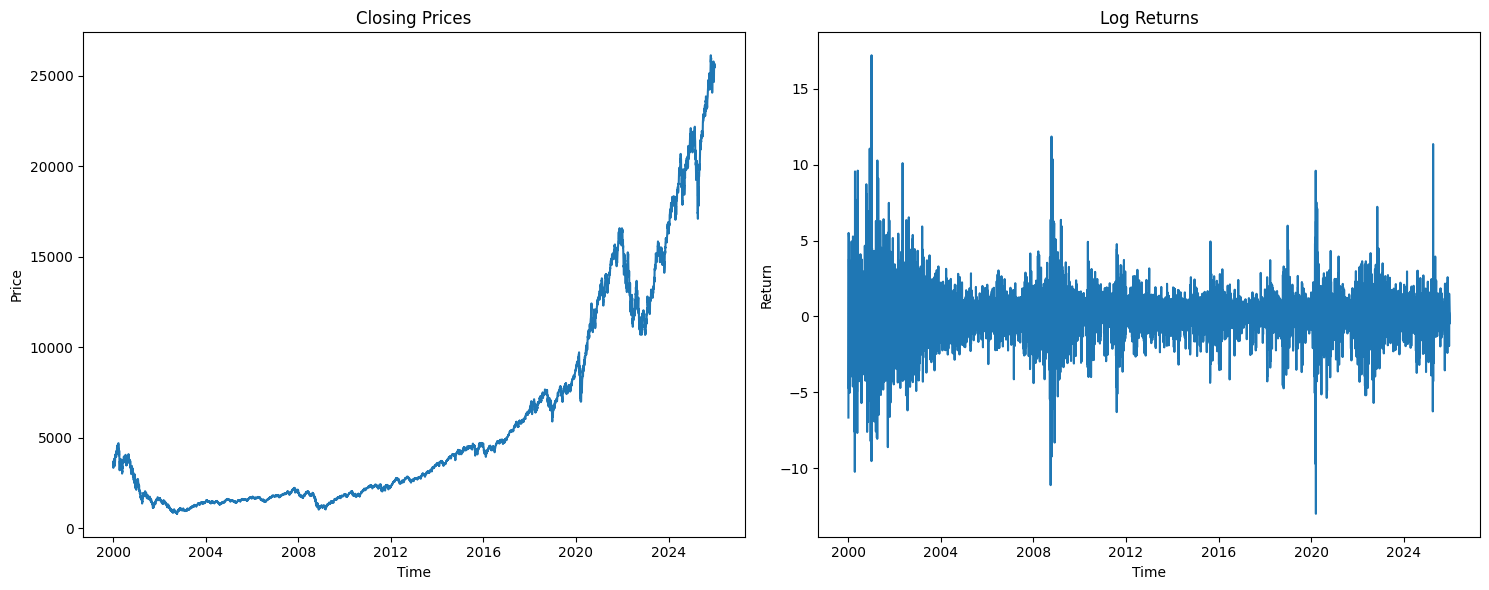

In [ ]:
# Plot closing prices and returns side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot closing prices
axes[0].plot(close)
axes[0].set_title("Closing Prices")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Price")

# Plot returns
axes[1].plot(returns)
axes[1].set_title("Log Returns")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Return")

plt.tight_layout()
plt.show()

In [ ]:
# Basic statistics
print("Basic statistics:")
print(returns.describe())
print("\nSkewness:", stats.skew(returns))
print("Kurtosis:", stats.kurtosis(returns))

Basic statistics:
count    6537.000000
mean        0.029137
std         1.720159
min       -13.003151
25%        -0.668304
50%         0.105733
75%         0.801194
max        17.202968
Name: Returns, dtype: float64

Skewness: 0.05186272311397513
Kurtosis: 7.170929200991811


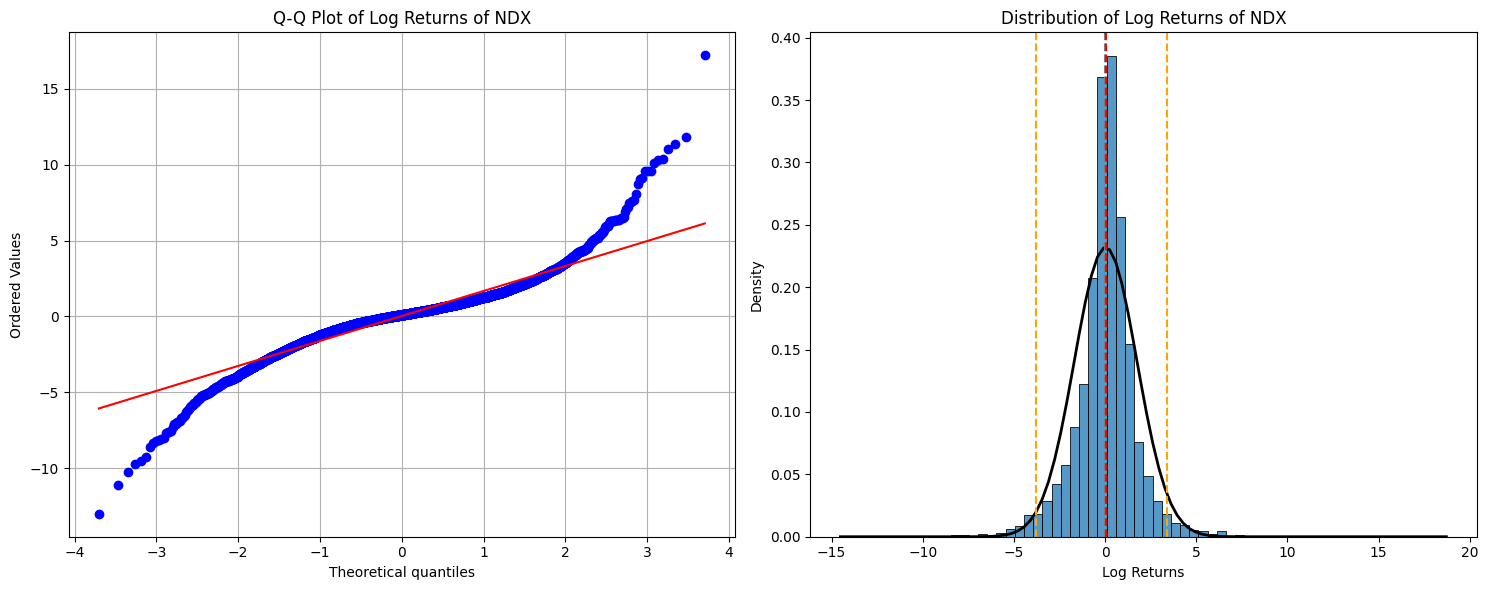

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Left: Q-Q Plot ---
stats.probplot(returns, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot of Log Returns of NDX')
axes[0].grid(True)

# --- Right: Histogram + Normal Curve ---
sns.histplot(returns, stat="density", bins=60, ax=axes[1])

mu, std = returns.mean(), returns.std()
xmin, xmax = axes[1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
axes[1].plot(x, p, 'k', linewidth=2)

axes[1].axvline(x=0, linestyle='--', color='gray')
axes[1].axvline(x=returns.mean(), linestyle='--', color='red')
axes[1].axvline(x=returns.quantile(0.025), linestyle='--', color='orange')
axes[1].axvline(x=returns.quantile(0.975), linestyle='--', color='orange')

axes[1].set_title('Distribution of Log Returns of NDX')
axes[1].set_xlabel('Log Returns')

plt.tight_layout()
plt.show()

In [ ]:
# Jarque-Bera test
jb_test = stats.jarque_bera(returns)
print(f"Jarque-Bera test statistic: {jb_test[0]:.2f}")
print(f"p-value: {jb_test[1]:.2e}")

Jarque-Bera test statistic: 14009.06
p-value: 0.00e+00


## RV

In [ ]:
# Basic statistics
print("Basic statistics:")
print(rv.describe())
print("\nSkewness:", stats.skew(rv))
print("Kurtosis:", stats.kurtosis(rv))

Basic statistics:
count    6515.000000
mean        1.371422
std         0.814407
min         0.418149
25%         0.836904
50%         1.084546
75%         1.630936
max         5.156902
Name: YZ_Vol, dtype: float64

Skewness: 1.9365644814982348
Kurtosis: 4.025632968924039


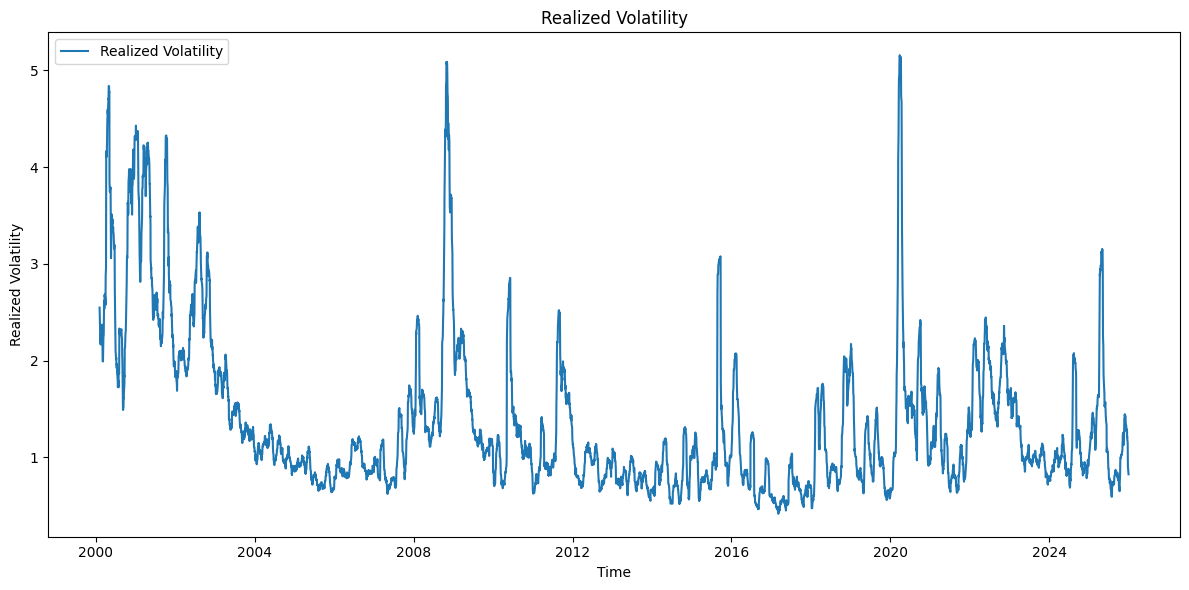

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Realized Volatility
ax.plot(rv, label='Realized Volatility')

ax.set_xlabel('Time')
ax.set_ylabel('Realized Volatility')
ax.tick_params(axis='y')

ax.legend(loc='upper left')

plt.title("Realized Volatility")
plt.tight_layout()
plt.show()

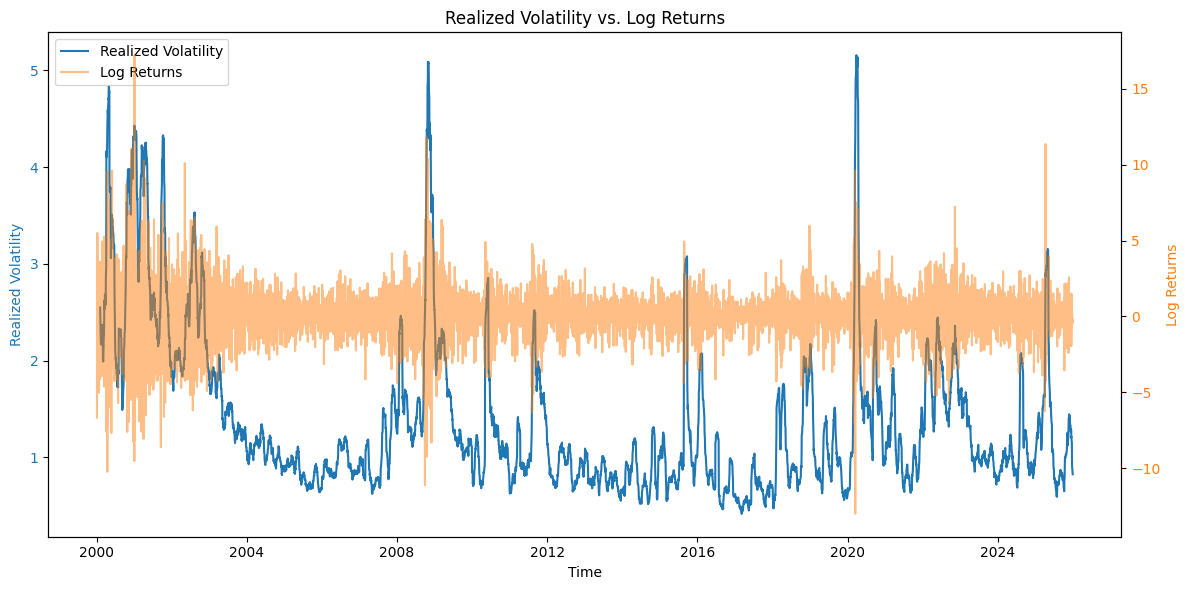

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Realized Volatility on the primary y-axis (left)
color1 = '#1f77b4'  # Blue
line1 = ax1.plot(rv, color=color1, label='Realized Volatility')
ax1.set_xlabel('Time')
ax1.set_ylabel('Realized Volatility', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Create a secondary y-axis sharing the same x-axis
ax2 = ax1.twinx()

# Plot Log Returns on the secondary y-axis (right)
color2 = '#ff7f0e'  # Orange / Amber
line2 = ax2.plot(returns, color=color2, alpha=0.5, label='Log Returns')
ax2.set_ylabel('Log Returns', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title("Realized Volatility vs. Log Returns")
plt.tight_layout()
plt.show()

# **Testing The Stationary of Returns and RV**

## Returns

### ADF Test

In [ ]:
def adf_test(series, max_aug=10, version='n'):

    results = []

    y = series.diff()
    X = pd.DataFrame({'y_lag': series.shift()})

    if version == 'c' or version == 't': # constant to be added optionally
        X = sm.add_constant(X)
    if version == 't': # (deterministic) trend component to be added optionally
        X['trend'] = range(len(X))

    for i in range(0, max_aug): # iterating through different numbers of augmentations

        for aug in range(1, i+1): # adding augmentations one by one until its current amount is reached
            X['aug_'+str(aug)] = y.shift(aug)

        model = sm.OLS(series.diff(), X, missing='drop').fit() # fitting a linear regression with OLS

        ts = model.tvalues['y_lag'] # test statistic
        nobs = model.nobs # number of observations

        if version == 'n': # critical values for basic version of ADF
            if nobs > 500:
                cv1 = -2.567; cv5 = -1.941; cv10 = -1.616 # critical values for more than 500 observations
            else:
                cv1 = np.nan; cv5 = np.nan; cv10 = np.nan # if number of observations is lower than 500, we should check the critical values manually
        if version == 'c': # critical values for version with constant
            if nobs > 500:
                cv1 = -3.434; cv5 = -2.863; cv10 = -2.568 # critical values for more than 500 observations
            else:
                cv1 = np.nan; cv5 = np.nan; cv10 = np.nan # if number of observations is lower than 500, we should check the critical values manually
        if version == 't': # critical values for version with constant and (deterministic) trend component
            if nobs > 500:
                cv1 = -3.963; cv5 = -3.413; cv10 = -3.128 # critical values for more than 500 observations
            else:
                cv1 = np.nan; cv5 = np.nan; cv10 = np.nan # if number of observations is lower than 500, we should check the critical values manually

        bg_test5 = smd.acorr_breusch_godfrey(model, nlags=5); bg_pvalue5 = round(bg_test5[1],4)
        bg_test5 = smd.acorr_breusch_godfrey(model, nlags=10); bg_pvalue10 = round(bg_test5[1],4)
        bg_test5 = smd.acorr_breusch_godfrey(model, nlags=15); bg_pvalue15 = round(bg_test5[1],4)

        results.append([i, ts, cv1, cv5, cv10, bg_pvalue5, bg_pvalue10, bg_pvalue15])

    results_df = pd.DataFrame(results)
    results_df.columns = ['number of augmentations', 'ADF test statistic', 'ADF critival value (1%)', 'ADF critival value (5%)', 'ADF critival value (10%)', 'BG test (5 lags) (p-value)', 'BG test (10 lags) (p-value)', 'BG test (15 lags) (p-value)']

    return results_df

In [ ]:
adf_test(close, max_aug=20)

,number of augmentations,ADF test statistic,ADF critival value (1%),ADF critival value (5%),ADF critival value (10%),BG test (5 lags) (p-value),BG test (10 lags) (p-value),BG test (15 lags) (p-value)
0,0,3.483216,-2.567,-1.941,-1.616,0.0000,0.0000,0.0000
1,1,3.888921,-2.567,-1.941,-1.616,0.0000,0.0000,0.0000
2,2,3.751897,-2.567,-1.941,-1.616,0.0000,0.0000,0.0000
3,3,3.970083,-2.567,-1.941,-1.616,0.0004,0.0000,0.0000
4,4,4.184156,-2.567,-1.941,-1.616,0.0044,0.0000,0.0000
5,5,4.200382,-2.567,-1.941,-1.616,0.4943,0.0001,0.0000
6,6,4.296084,-2.567,-1.941,-1.616,0.0000,0.0001,0.0001
7,7,4.133150,-2.567,-1.941,-1.616,0.0001,0.0006,0.0013
8,8,4.327353,-2.567,-1.941,-1.616,0.0148,0.0363,0.0001
9,9,4.086355,-2.567,-1.941,-1.616,0.3182,0.0122,0.0012


In [ ]:
adf_test(returns, max_aug=26)

,number of augmentations,ADF test statistic,ADF critival value (1%),ADF critival value (5%),ADF critival value (10%),BG test (5 lags) (p-value),BG test (10 lags) (p-value),BG test (15 lags) (p-value)
0,0,-87.471781,-2.567,-1.941,-1.616,0.0015,0.0000,0.0000
1,1,-62.278845,-2.567,-1.941,-1.616,0.0004,0.0000,0.0000
2,2,-49.837433,-2.567,-1.941,-1.616,0.0000,0.0000,0.0000
3,3,-42.544704,-2.567,-1.941,-1.616,0.0000,0.0000,0.0000
4,4,-38.183522,-2.567,-1.941,-1.616,0.0000,0.0000,0.0000
5,5,-35.485015,-2.567,-1.941,-1.616,0.2596,0.0000,0.0000
6,6,-31.353031,-2.567,-1.941,-1.616,0.0000,0.0000,0.0000
7,7,-30.842883,-2.567,-1.941,-1.616,0.0108,0.0048,0.0000
8,8,-28.086864,-2.567,-1.941,-1.616,0.0434,0.0019,0.0000
9,9,-26.791603,-2.567,-1.941,-1.616,0.0009,0.0000,0.0000


### Phillips Perron Test

In [ ]:
pp = PhillipsPerron(close)
print(pp.summary())

     Phillips-Perron Test (Z-tau)    
Test Statistic                  3.320
P-value                         1.000
Lags                               35
-------------------------------------

Trend: Constant
Critical Values: -3.43 (1%), -2.86 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:
pp = PhillipsPerron(returns)
print(pp.summary())

     Phillips-Perron Test (Z-tau)    
Test Statistic                -87.984
P-value                         0.000
Lags                               35
-------------------------------------

Trend: Constant
Critical Values: -3.43 (1%), -2.86 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


## RV

### ADF Test

In [ ]:
adf_test(rv, max_aug=90)

,number of augmentations,ADF test statistic,ADF critival value (1%),ADF critival value (5%),ADF critival value (10%),BG test (5 lags) (p-value),BG test (10 lags) (p-value),BG test (15 lags) (p-value)
0,0,-1.958707,-2.567,-1.941,-1.616,0.0000,0.0000,0.0000
1,1,-2.413181,-2.567,-1.941,-1.616,0.0000,0.0000,0.0000
2,2,-2.760756,-2.567,-1.941,-1.616,0.0000,0.0000,0.0000
3,3,-2.979876,-2.567,-1.941,-1.616,0.0000,0.0000,0.0000
4,4,-3.153364,-2.567,-1.941,-1.616,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...
85,85,-2.275348,-2.567,-1.941,-1.616,0.0000,0.0000,0.0000
86,86,-2.269666,-2.567,-1.941,-1.616,0.0000,0.0000,0.0000
87,87,-2.217247,-2.567,-1.941,-1.616,0.0000,0.0000,0.0000
88,88,-2.104805,-2.567,-1.941,-1.616,0.0262,0.0941,0.0405


### Phillips Perron Test

In [ ]:
pp = PhillipsPerron(rv)
print(pp.summary())

     Phillips-Perron Test (Z-tau)    
Test Statistic                 -5.780
P-value                         0.000
Lags                               35
-------------------------------------

Trend: Constant
Critical Values: -3.43 (1%), -2.86 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


# **Verification of ARCH Effect**

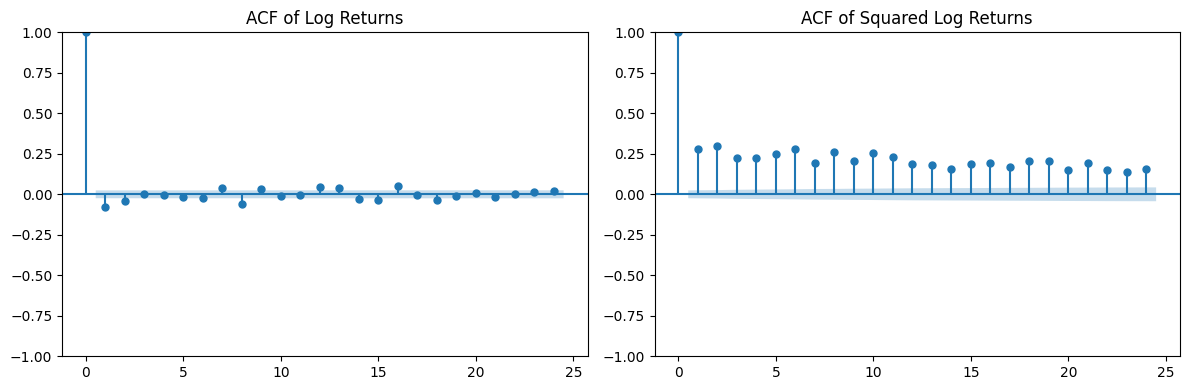

In [ ]:
# ACF function
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ACF of log returns
plot_acf(returns, lags=24, ax=axes[0])
axes[0].set_title("ACF of Log Returns")

# ACF of squared log returns
plot_acf(returns**2, lags=24, ax=axes[1])
axes[1].set_title("ACF of Squared Log Returns")

plt.tight_layout()
plt.show()

In [ ]:
# ARCH test (Engle's LM test)
# H0: No ARCH effects
# H1: ARCH effects are present

arch_test_results = het_arch(returns, nlags=5)

print(f"LM Statistic: {arch_test_results[0]:.3f}")
print(f"p-value: {arch_test_results[1]:.3f}")
print(f"F-statistic: {arch_test_results[2]:.3f}")
print(f"F p-value: {arch_test_results[3]:.3f}")

LM Statistic: 1073.417
p-value: 0.000
F-statistic: 256.664
F p-value: 0.000
